In [11]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:


df = pd.read_csv("a.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (1836, 10)


,id,country,state,city,station,pollutant_id,last_update,pollutant_min,pollutant_max,pollutant_avg
0,1,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,21-10-2021 01:00:00,69.0,109.0,86.0
1,2,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,21-10-2021 01:00:00,82.0,138.0,105.0
2,3,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,21-10-2021 01:00:00,10.0,42.0,19.0
3,4,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,21-10-2021 01:00:00,4.0,5.0,4.0
4,5,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,21-10-2021 01:00:00,16.0,42.0,27.0


In [13]:


print("Dataset Information")
print("=" * 60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1836 non-null   int64  
 1   country        1836 non-null   object 
 2   state          1836 non-null   object 
 3   city           1836 non-null   object 
 4   station        1836 non-null   object 
 5   pollutant_id   1836 non-null   object 
 6   last_update    1836 non-null   object 
 7   pollutant_min  1738 non-null   float64
 8   pollutant_max  1738 non-null   float64
 9   pollutant_avg  1738 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 143.6+ KB


In [14]:


rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 1836
Number of Columns: 10


In [15]:

print("Columns in Dataset")
print("=" * 60)

for column in df.columns:
    print(column)

Columns in Dataset
id
country
state
city
station
pollutant_id
last_update
pollutant_min
pollutant_max
pollutant_avg


In [16]:


df.head(10)

,id,country,state,city,station,pollutant_id,last_update,pollutant_min,pollutant_max,pollutant_avg
0,1,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,21-10-2021 01:00:00,69.0,109.0,86.0
1,2,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,21-10-2021 01:00:00,82.0,138.0,105.0
2,3,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,21-10-2021 01:00:00,10.0,42.0,19.0
3,4,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,21-10-2021 01:00:00,4.0,5.0,4.0
4,5,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,21-10-2021 01:00:00,16.0,42.0,27.0
5,6,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",CO,21-10-2021 01:00:00,15.0,45.0,32.0
6,7,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",OZONE,21-10-2021 01:00:00,4.0,82.0,42.0
7,8,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",PM2.5,21-10-2021 01:00:00,47.0,111.0,71.0
8,9,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",PM10,21-10-2021 01:00:00,49.0,120.0,86.0
9,10,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",NO2,21-10-2021 01:00:00,11.0,44.0,23.0


In [17]:


df.tail(10)

,id,country,state,city,station,pollutant_id,last_update,pollutant_min,pollutant_max,pollutant_avg
1826,1827,India,West_Bengal,Kolkata,"Rabindra Sarobar, Kolkata - WBPCB",SO2,21-10-2021 01:00:00,2.0,15.0,4.0
1827,1828,India,West_Bengal,Kolkata,"Rabindra Sarobar, Kolkata - WBPCB",CO,21-10-2021 01:00:00,31.0,85.0,39.0
1828,1829,India,West_Bengal,Kolkata,"Rabindra Sarobar, Kolkata - WBPCB",OZONE,21-10-2021 01:00:00,6.0,76.0,31.0
1829,1830,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",PM2.5,21-10-2021 01:00:00,28.0,75.0,54.0
1830,1831,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",PM10,21-10-2021 01:00:00,36.0,101.0,74.0
1831,1832,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",NO2,21-10-2021 01:00:00,10.0,22.0,15.0
1832,1833,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",NH3,21-10-2021 01:00:00,1.0,3.0,2.0
1833,1834,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",SO2,21-10-2021 01:00:00,6.0,28.0,10.0
1834,1835,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",CO,21-10-2021 01:00:00,34.0,92.0,41.0
1835,1836,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",OZONE,21-10-2021 01:00:00,10.0,116.0,43.0


In [18]:


df.describe()

,id,pollutant_min,pollutant_max,pollutant_avg
count,1836.000000,1738.000000,1738.000000,1738.000000
mean,918.500000,28.414269,96.873418,54.100690
std,530.151865,34.403811,104.765094,60.824158
min,1.000000,1.000000,1.000000,1.000000
25%,459.750000,5.000000,21.000000,12.000000
50%,918.500000,14.000000,63.000000,31.000000
75%,1377.250000,39.000000,124.000000,70.000000
max,1836.000000,217.000000,500.000000,314.000000


In [19]:


print("Missing Values")
print("=" * 60)

print(df.isnull().sum())

Missing Values
id                0
country           0
state             0
city              0
station           0
pollutant_id      0
last_update       0
pollutant_min    98
pollutant_max    98
pollutant_avg    98
dtype: int64


In [20]:


duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


In [21]:


df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (1836, 10)


In [22]:


print(df.dtypes)

id                 int64
country           object
state             object
city              object
station           object
pollutant_id      object
last_update       object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object


In [23]:


print("Pollutant Types:")
print(df["pollutant_id"].unique())

Pollutant Types:
['PM2.5' 'PM10' 'NO2' 'NH3' 'SO2' 'CO' 'OZONE']


In [24]:

print(df["pollutant_id"].value_counts())

pollutant_id
CO       273
PM2.5    272
NO2      271
PM10     267
SO2      260
OZONE    258
NH3      235
Name: count, dtype: int64


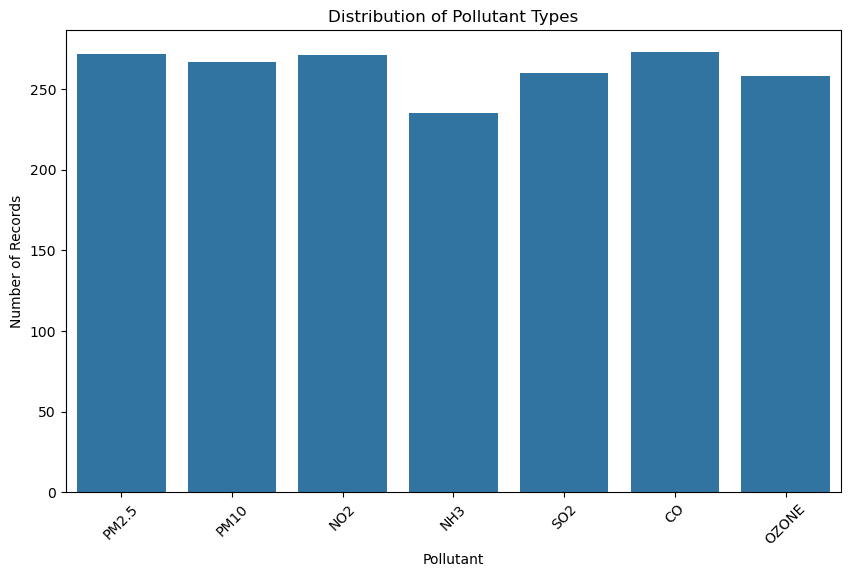

In [25]:


plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="pollutant_id"
)

plt.title("Distribution of Pollutant Types")
plt.xlabel("Pollutant")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

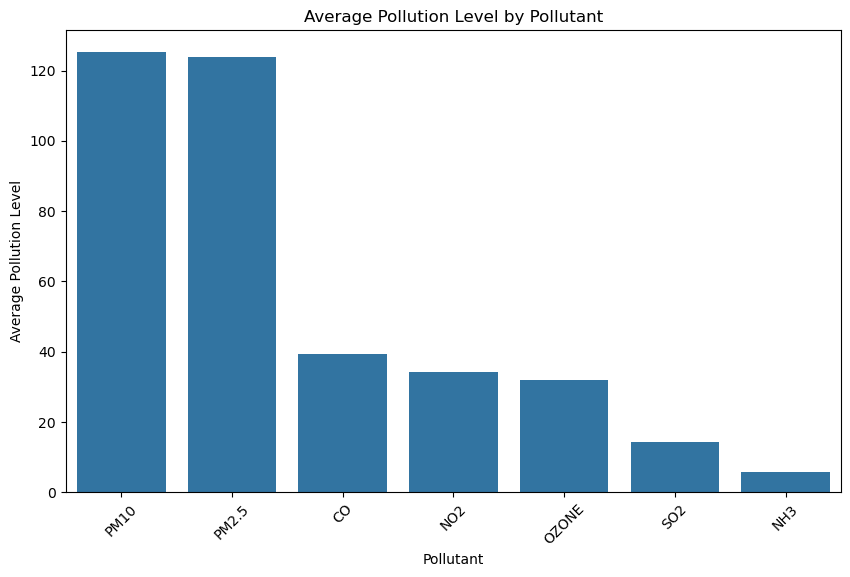

In [26]:


pollutant_avg = (
    df.groupby("pollutant_id")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pollutant_avg.index,
    y=pollutant_avg.values
)

plt.title("Average Pollution Level by Pollutant")
plt.xlabel("Pollutant")
plt.ylabel("Average Pollution Level")

plt.xticks(rotation=45)

plt.show()

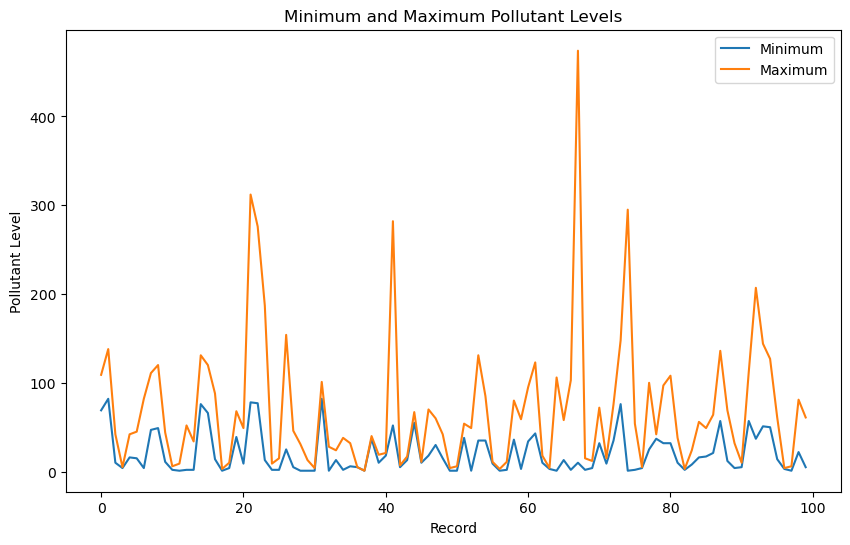

In [27]:


plt.figure(figsize=(10, 6))

plt.plot(
    df["pollutant_min"].values[:100],
    label="Minimum"
)

plt.plot(
    df["pollutant_max"].values[:100],
    label="Maximum"
)

plt.title("Minimum and Maximum Pollutant Levels")
plt.xlabel("Record")
plt.ylabel("Pollutant Level")

plt.legend()

plt.show()

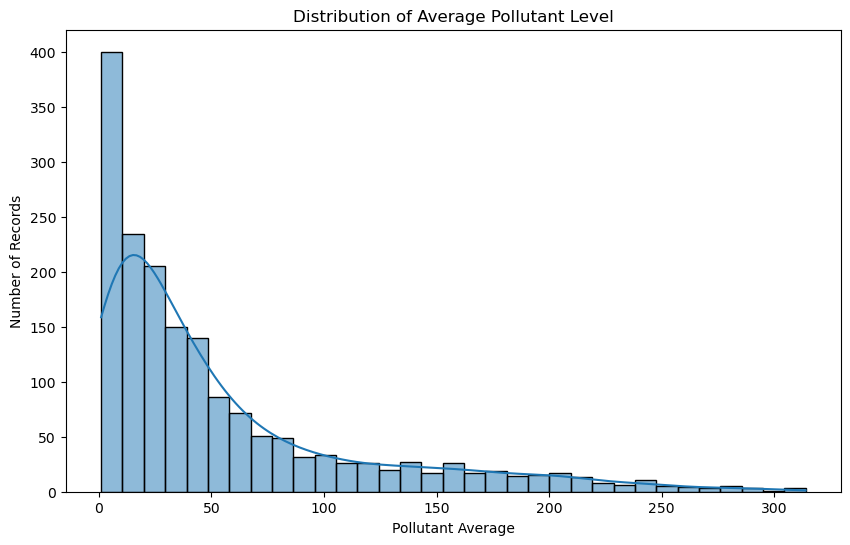

In [29]:


plt.figure(figsize=(10, 6))

sns.histplot(
    df["pollutant_avg"],
    kde=True
)

plt.title("Distribution of Average Pollutant Level")
plt.xlabel("Pollutant Average")
plt.ylabel("Number of Records")

plt.show()

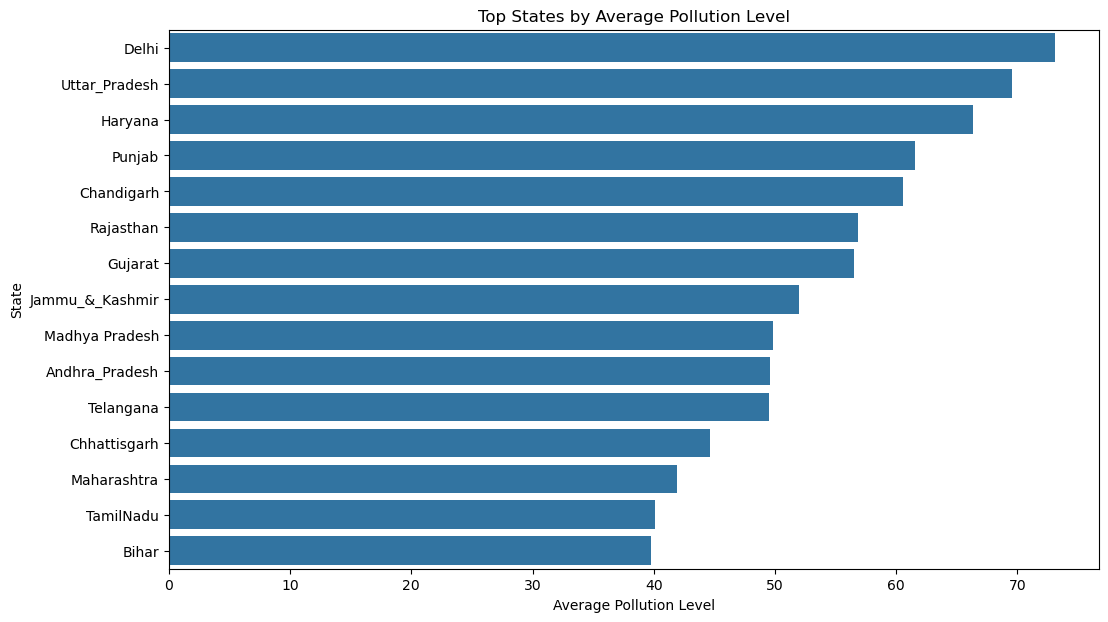

In [30]:


state_avg = (
    df.groupby("state")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_avg.values,
    y=state_avg.index
)

plt.title("Top States by Average Pollution Level")
plt.xlabel("Average Pollution Level")
plt.ylabel("State")

plt.show()

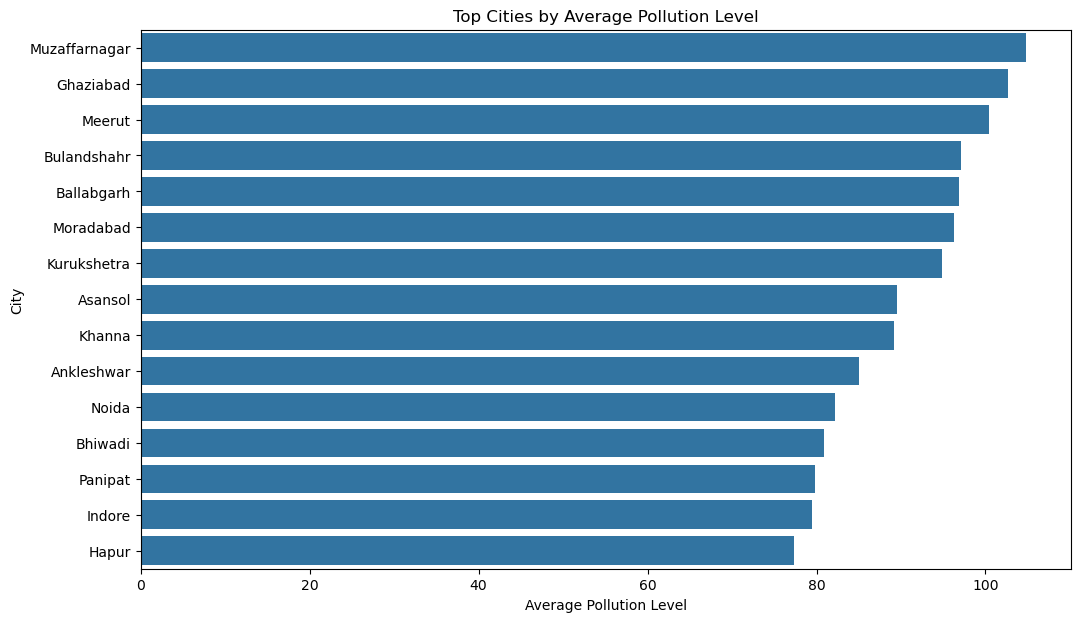

In [31]:


city_avg = (
    df.groupby("city")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_avg.values,
    y=city_avg.index
)

plt.title("Top Cities by Average Pollution Level")
plt.xlabel("Average Pollution Level")
plt.ylabel("City")

plt.show()

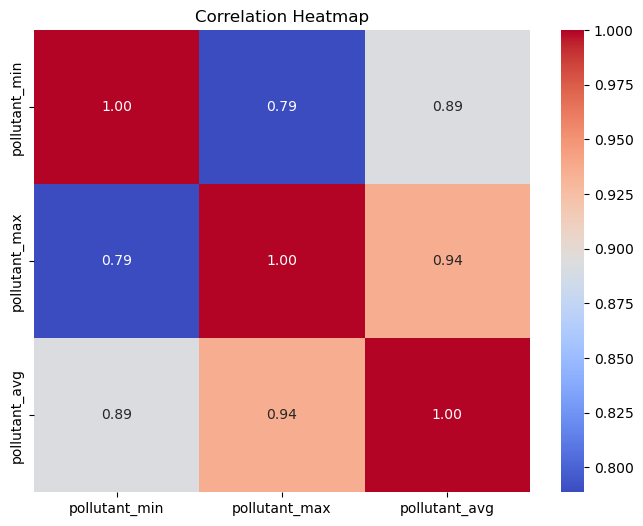

In [32]:


numeric_columns = [
    "pollutant_min",
    "pollutant_max",
    "pollutant_avg"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [33]:


model_df = df.copy()

# Select useful columns

model_df = model_df[
    [
        "state",
        "city",
        "station",
        "pollutant_id",
        "pollutant_min",
        "pollutant_max",
        "pollutant_avg"
    ]
]

model_df.head()

,state,city,station,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,69.0,109.0,86.0
1,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,82.0,138.0,105.0
2,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,10.0,42.0,19.0
3,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,4.0,5.0,4.0
4,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,16.0,42.0,27.0


In [34]:


print(model_df.isnull().sum())

state             0
city              0
station           0
pollutant_id      0
pollutant_min    98
pollutant_max    98
pollutant_avg    98
dtype: int64


In [35]:


model_df = model_df.dropna()

print("Dataset shape after cleaning:", model_df.shape)

Dataset shape after cleaning: (1738, 7)


In [36]:


state_encoder = LabelEncoder()
city_encoder = LabelEncoder()
station_encoder = LabelEncoder()
pollutant_encoder = LabelEncoder()

# Encode categorical columns

model_df["state_encoded"] = state_encoder.fit_transform(
    model_df["state"]
)

model_df["city_encoded"] = city_encoder.fit_transform(
    model_df["city"]
)

model_df["station_encoded"] = station_encoder.fit_transform(
    model_df["station"]
)

model_df["pollutant_encoded"] = pollutant_encoder.fit_transform(
    model_df["pollutant_id"]
)

model_df.head()

,state,city,station,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,state_encoded,city_encoded,station_encoded,pollutant_encoded
0,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,69.0,109.0,86.0,0,6,214,5
1,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,82.0,138.0,105.0,0,6,214,4
2,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,10.0,42.0,19.0,0,6,214,2
3,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,4.0,5.0,4.0,0,6,214,1
4,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,16.0,42.0,27.0,0,6,214,6


In [37]:


X = model_df[
    [
        "state_encoded",
        "city_encoded",
        "station_encoded",
        "pollutant_encoded",
        "pollutant_min",
        "pollutant_max"
    ]
]

# Target variable

y = model_df["pollutant_avg"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1738, 6)
Target Shape: (1738,)


In [38]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 1390
Testing Samples: 348


In [39]:


model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [40]:


model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [41]:


y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Predictions:
[ 6.21  46.29   3.64  19.145 75.745 56.4    1.915  8.595  5.195 12.6  ]


In [42]:


mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Mean Absolute Error (MAE):", round(mae, 2))

Mean Absolute Error (MAE): 7.0


In [43]:


mse = mean_squared_error(
    y_test,
    y_pred
)

# Root Mean Squared Error

rmse = np.sqrt(mse)

print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Squared Error (MSE): 189.97
Root Mean Squared Error (RMSE): 13.78


In [44]:
# R² Score

r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", round(r2, 4))

R² Score: 0.9462


In [45]:


print("=" * 55)
print("           MODEL PERFORMANCE")
print("=" * 55)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

print("=" * 55)

           MODEL PERFORMANCE
MAE  : 7.00
MSE  : 189.97
RMSE : 13.78
R²   : 0.9462


In [46]:


comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,4.0,6.210
1,44.0,46.290
2,4.0,3.640
3,19.0,19.145
4,84.0,75.745
5,53.0,56.400
6,2.0,1.915
7,12.0,8.595
8,3.0,5.195
9,12.0,12.600


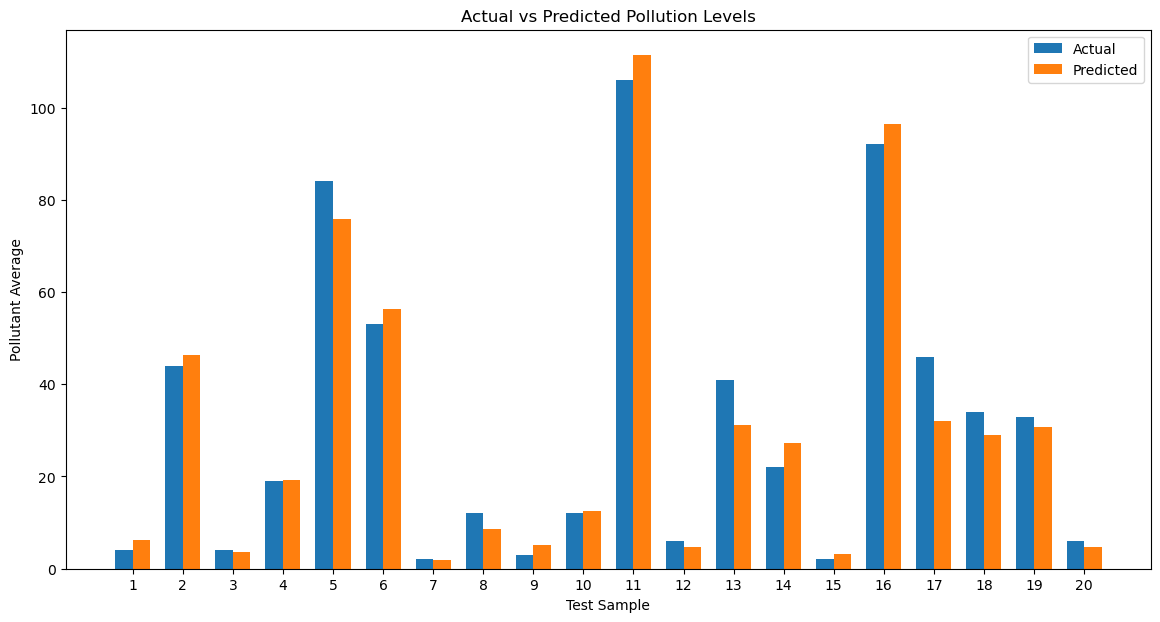

In [47]:


comparison_sample = comparison.head(20)

x = np.arange(len(comparison_sample))
width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    comparison_sample["Actual"],
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    comparison_sample["Predicted"],
    width,
    label="Predicted"
)

plt.title("Actual vs Predicted Pollution Levels")
plt.xlabel("Test Sample")
plt.ylabel("Pollutant Average")

plt.xticks(x, range(1, len(comparison_sample) + 1))

plt.legend()

plt.show()

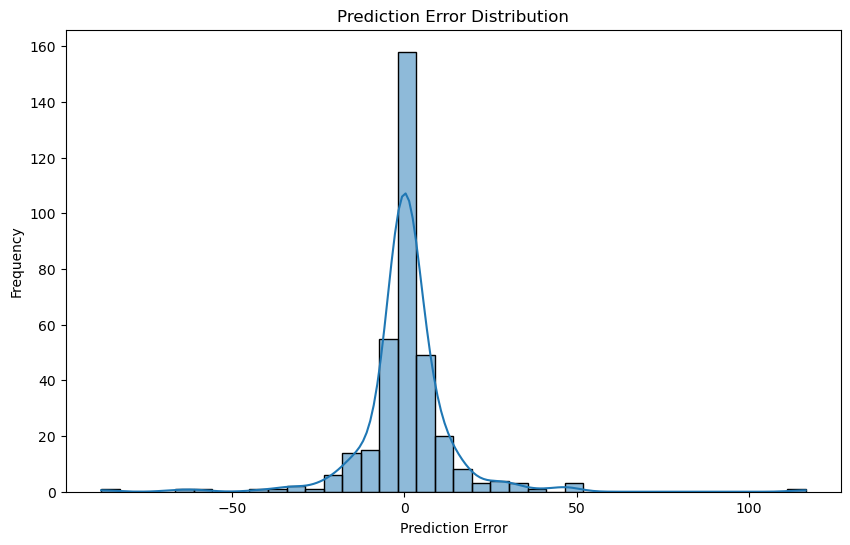

In [48]:


errors = y_test.values - y_pred

plt.figure(figsize=(10, 6))

sns.histplot(
    errors,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [49]:


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,pollutant_max,0.824603
4,pollutant_min,0.147499
2,station_encoded,0.008560
1,city_encoded,0.007259
3,pollutant_encoded,0.006155
0,state_encoded,0.005925


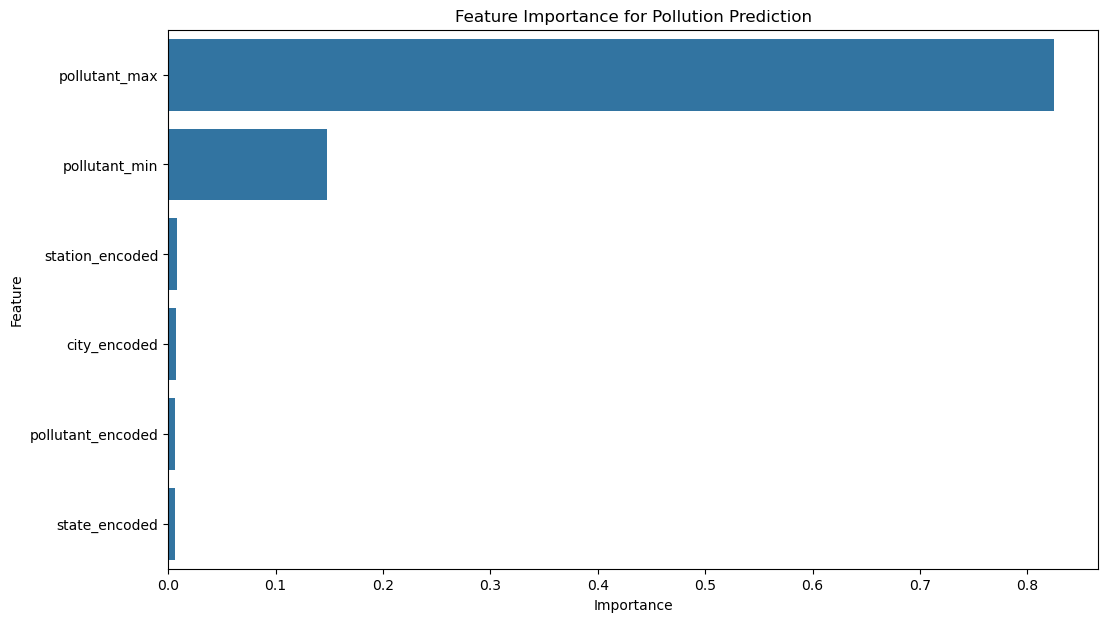

In [50]:


plt.figure(figsize=(12, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Pollution Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [51]:


joblib.dump(
    model,
    "air_pollution_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [52]:


joblib.dump(
    state_encoder,
    "state_encoder.pkl"
)

joblib.dump(
    city_encoder,
    "city_encoder.pkl"
)

joblib.dump(
    station_encoder,
    "station_encoder.pkl"
)

joblib.dump(
    pollutant_encoder,
    "pollutant_encoder.pkl"
)

print("All encoders saved successfully!")

All encoders saved successfully!


In [53]:


loaded_model = joblib.load(
    "air_pollution_model.pkl"
)

# Load encoders

loaded_state_encoder = joblib.load(
    "state_encoder.pkl"
)

loaded_city_encoder = joblib.load(
    "city_encoder.pkl"
)

loaded_station_encoder = joblib.load(
    "station_encoder.pkl"
)

loaded_pollutant_encoder = joblib.load(
    "pollutant_encoder.pkl"
)

print("Model and encoders loaded successfully!")

Model and encoders loaded successfully!


In [ ]:

print("=" * 60)
print("        AIR QUALITY PREDICTION SYSTEM")
print("=" * 60)

state = input("Enter State: ")
city = input("Enter City: ")
station = input("Enter Station: ")
pollutant = input("Enter Pollutant ID: ")

pollutant_min = float(
    input("Enter Minimum Pollutant Level: ")
)

pollutant_max = float(
    input("Enter Maximum Pollutant Level: ")
)


# Encode user inputs

state_encoded = loaded_state_encoder.transform(
    [state]
)[0]

city_encoded = loaded_city_encoder.transform(
    [city]
)[0]

station_encoded = loaded_station_encoder.transform(
    [station]
)[0]

pollutant_encoded = loaded_pollutant_encoder.transform(
    [pollutant]
)[0]


# Create input dataframe

new_data = pd.DataFrame([[
    state_encoded,
    city_encoded,
    station_encoded,
    pollutant_encoded,
    pollutant_min,
    pollutant_max
]], columns=[
    "state_encoded",
    "city_encoded",
    "station_encoded",
    "pollutant_encoded",
    "pollutant_min",
    "pollutant_max"
])


# Predict

prediction = loaded_model.predict(
    new_data
)[0]


print("\n" + "=" * 60)
print("          PREDICTION RESULT")
print("=" * 60)

print(
    f"Predicted Average Pollutant Level: {prediction:.2f}"
)

print("=" * 60)

        AIR QUALITY PREDICTION SYSTEM
